# BinX Week 06 — Day 1: Sprint 1 Kickoff & Baseline Model

| Field | Value |
|:------|:------|
| **Phase** | Phase 3 — Deep Learning & Applied Project |
| **Sprint** | Sprint 1 of 4 (Weeks 6–9) |
| **Day** | Day 1 of 5 |
| **Dataset** | `Data/processed/heart_disease_processed.csv` |
| **Notebook** | `BinX_Week_06/Day1/sprint1_baseline.ipynb` |

---
## Sprint 1 — Events & Timeline

Phase 3 runs across **4 one-week sprints**. Sprint 1 (Week 6) follows the standard sprint cycle:

| Event | When | Description |
|:------|:-----|:------------|
| **Sprint Planning** | Day 1 | Confirm the Sprint 1 goal from Week 5, select backlog tasks (dataset, EDA, baseline), commit to the sprint goal. |
| **Daily Stand-up** | Daily | 3-minute update: what was completed, what is next, any blockers (data issues, model errors). |
| **Mentor Code & Notebook Review** | Day 3 | Mentor reviews the notebook and code via GitHub pull request; structured comments on methodology and results. |
| **Sprint Review** | Day 5 | Demo completed pipeline stages / model results. Incomplete tasks move to Sprint 2 with documented reasons. |
| **Sprint Retrospective** | Day 5 | What went well, what to improve, and one specific action for Sprint 2. |

> **Notebook Workflow:** All work is committed to GitHub via **feature branches**. A pull request is opened for mentor review before merging to `main`.

---
## Sprint 1 Goal

> **Establish a robust, reproducible machine learning baseline pipeline on the Heart Disease dataset
> using standard tabular modeling techniques. The evaluation metrics recorded today establish the
> absolute benchmark that every neural network architecture developed in subsequent days must outperform.**

### Why Baseline First?

Sprint 1's real objective is to establish a baseline — a simple model (from Weeks 3–4) whose score every later model, including this week's neural network, **must beat**. Without a baseline, a neural network's score is meaningless.

| Principle | Meaning |
|:----------|:--------|
| **Baseline First** | Always compare against a simple model before building complex ones |
| **No Leakage** | Test set is never touched during training, scaling, or imputation |
| **Reproducibility** | Fixed `random_state`, committed `requirements.txt` |

---
## Sprint 1 Backlog — Task Ordering & Acceptance Criteria

Tasks are ordered by dependency. Each task has written acceptance criteria before work begins.

| # | Task | Description | Acceptance Criteria |
|:-:|:-----|:------------|:--------------------|
| 1 | **Data Ingestion & Schema Validation** | Load dataset, verify shape, dtypes, missing values | Dataset loaded; shape printed; dtypes verified; no missing values (or documented) |
| 2 | **Exploratory Data Analysis (EDA)** | Statistical summary, distributions, outlier detection, correlation analysis | All numeric features profiled; outliers flagged via IQR; correlation heatmap produced |
| 3 | **Preprocessing Pipeline Assembly** | Build leakage-free Scikit-learn Pipeline with imputation, scaling, encoding | Pipeline object created; ColumnTransformer handles numeric + categorical; fitted on train only |
| 4 | **Baseline Model Training** | Train Logistic Regression, evaluate with Accuracy, F1, ROC-AUC | Model trained; all 3 metrics reported; confusion matrix printed |
| 5 | **Metric Logging & Benchmark Definition** | Document baseline scores; define minimum targets for neural network | Markdown table with scores; acceptance thresholds stated for Days 4–5 |

### Definition of Done (per Task)

- [ ] Notebook cell runs without errors
- [ ] Code is committed to the correct feature branch with a clear message
- [ ] A pull request is opened for mentor review before merging
- [ ] Results are documented in Markdown cells
- [ ] Metrics are logged and compared to the baseline

---
##  Sprint 1 Deliverables Checklist

By the end of Sprint 1 (Day 5), the following must be submitted:

- [ ] Completed Sprint 1 plan (goal, backlog) — **this notebook**
- [ ] Trained baseline model with recorded metrics — **this notebook**
- [ ] Activations & forward-pass notebook (Days 2–3 work)
- [ ] Training-mechanics notebook: training loop, learning-rate experiments, loss curves
- [ ] Trained Keras neural network with compile/fit/evaluate, dropout/batch-norm, diagnosed loss curves
- [ ] Tuning experiments with EarlyStopping, and a metric table comparing the network to the baseline
- [ ] All Sprint 1 work committed to GitHub via reviewed pull requests
- [ ] Written Sprint Retrospective

### Professional Baseline (Definition of Done — Full Capstone)

Every capstone project must eventually meet:
- Clean, documented Jupyter Notebook covering the full pipeline (EDA → preprocessing → modelling → evaluation)
- Trained model with reported metrics
- Working deployment at a public URL (Streamlit or FastAPI)
- GitHub repo with a clean `README.md`, `requirements.txt`, and model artifacts
- Short technical write-up

In [1]:
# ─── Core Libraries ───
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ─── Scikit-learn ───
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix,
)

# ─── Plot Defaults ───
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

print("✓ All libraries loaded successfully.")

✓ All libraries loaded successfully.


---
##  Task 1 & 2: Data Ingestion & Exploratory Data Analysis (EDA)

Following the **Week 2 EDA methodology**, we perform a systematic analysis:

| Step | What We Do | Why |
|:-----|:-----------|:----|
| **2.1** Dataset Overview | Shape, dtypes, missing values | Verify data integrity before modeling |
| **2.2** Statistical Summary | Mean, median, std, skewness, kurtosis | Understand central tendency & spread |
| **2.3** Target Distribution | Class balance assessment | Detect imbalance (affects metric choice) |
| **2.4** Univariate Analysis | Histograms + KDE, box plots | See distributions & identify outliers |
| **2.5** Outlier Detection | IQR method | Flag extreme values for investigation |
| **2.6** Correlation Analysis | Heatbar, top features with target | Identify strongest predictors |
| **2.7** Data Storytelling | Key findings & modeling implications | Translate analysis into decisions |

### 2.1 Dataset Overview

In [2]:
DATA_PATH = "../../Data/processed/heart_disease_processed.csv"
df = pd.read_csv(DATA_PATH)

print(f"Dataset Dimensions: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn Names: {df.columns.tolist()}")
print(f"\nData Types:")
print(df.dtypes)
print(f"\nMissing Values per Column:")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

Dataset Dimensions: 918 rows × 14 columns

Column Names: ['country', 'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'num', 'target']

Data Types:
country         str
age         float64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
num           int64
target        int64
dtype: object

Missing Values per Column:
No missing values found.


In [3]:
df.head(10)

,country,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,num,target
0,Cleveland (USA),63.0,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,0
1,Cleveland (USA),67.0,1,4,160.0,286.0,0,2,108.0,1,1.5,2,2,1
2,Cleveland (USA),67.0,1,4,120.0,229.0,0,2,129.0,1,2.6,2,1,1
3,Cleveland (USA),37.0,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,0
4,Cleveland (USA),41.0,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,0
5,Cleveland (USA),56.0,1,2,120.0,236.0,0,0,178.0,0,0.8,1,0,0
6,Cleveland (USA),62.0,0,4,140.0,268.0,0,2,160.0,0,3.6,3,3,1
7,Cleveland (USA),57.0,0,4,120.0,354.0,0,0,163.0,1,0.6,1,0,0
8,Cleveland (USA),63.0,1,4,130.0,254.0,0,2,147.0,0,1.4,2,2,1
9,Cleveland (USA),53.0,1,4,140.0,203.0,1,2,155.0,1,3.1,3,1,1


### 2.2 Statistical Summary — Central Tendency & Spread

Understanding the center (mean, median) and spread (std, IQR) helps identify:
- Features with very different scales → need `StandardScaler`
- Skewed distributions → mean ≠ median
- High variability → may need transformation

In [4]:
# Numeric features — exclude target columns ('num' is multi-class target, 'target' is binary target)
TARGET_COLS = ['num', 'target']
numeric_cols = [c for c in df.select_dtypes(include=['int64', 'float64']).columns if c not in TARGET_COLS]
categorical_cols = df.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")
print(f"Categorical features ({len(categorical_cols)}): {categorical_cols}")
print(f"Target columns (excluded from features): {TARGET_COLS}")
print("\n" + "=" * 70)
print("STATISTICAL SUMMARY — NUMERIC FEATURES")
print("=" * 70)

stats = df[numeric_cols].describe().T
stats['skewness'] = df[numeric_cols].skew()
stats['kurtosis'] = df[numeric_cols].kurtosis()
stats.round(3)

Numeric features (11): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope']
Categorical features (1): ['country']
Target columns (excluded from features): ['num', 'target']

STATISTICAL SUMMARY — NUMERIC FEATURES


,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
age,918.0,53.511,9.433,28.0,47.00,54.0,60.00,77.0,-0.196,-0.386
sex,918.0,0.790,0.408,0.0,1.00,1.0,1.00,1.0,-1.425,0.029
cp,918.0,3.252,0.931,1.0,3.00,4.0,4.00,4.0,-0.893,-0.434
trestbps,918.0,132.131,17.928,80.0,120.00,130.0,140.00,200.0,0.679,0.906
chol,918.0,244.171,52.040,85.0,217.25,236.0,267.00,603.0,1.612,7.028
fbs,918.0,0.150,0.358,0.0,0.00,0.0,0.00,1.0,1.960,1.846
restecg,918.0,0.603,0.806,0.0,0.00,0.0,1.00,2.0,0.839,-0.948
thalach,918.0,136.514,25.483,60.0,120.00,138.0,155.75,202.0,-0.107,-0.471
exang,918.0,0.424,0.494,0.0,0.00,0.0,1.00,1.0,0.309,-1.909
oldpeak,918.0,0.938,1.039,0.0,0.00,0.7,1.50,6.2,1.089,1.132


### 2.3 Target Distribution — Class Balance Assessment

Class imbalance affects model evaluation. If one class dominates, **accuracy alone is misleading** — we must rely on **F1-score, precision, recall, and ROC-AUC**.

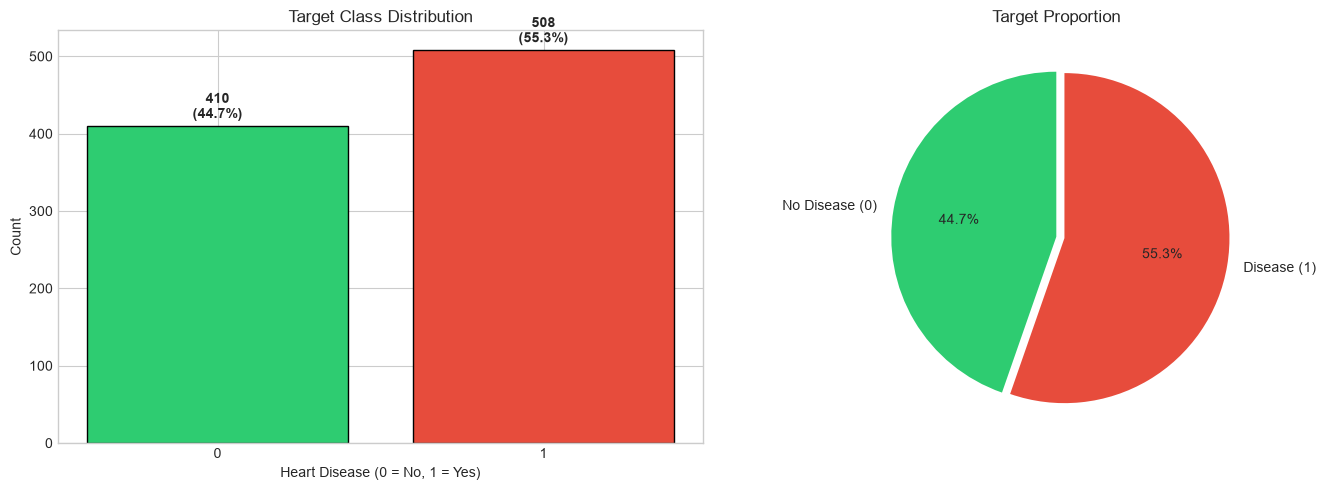


Class Imbalance Ratio: 1.24x
Interpretation: Mild imbalance — accuracy is acceptable, but F1/ROC-AUC preferred.


In [5]:
TARGET_COL = 'target'

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Target class distribution
target_counts = df[TARGET_COL].value_counts().sort_index()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')
axes[0].set_title("Target Class Distribution")
axes[0].set_xlabel("Heart Disease (0 = No, 1 = Yes)")
axes[0].set_ylabel("Count")
axes[0].set_xticks([0, 1])

for bar, count in zip(bars, target_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{count}\n({count/len(df)*100:.1f}%)', ha='center', va='bottom', fontweight='bold')

# Pie chart
axes[1].pie(target_counts.values, labels=['No Disease (0)', 'Disease (1)'],
            autopct='%1.1f%%', colors=colors, startangle=90, explode=(0, 0.05))
axes[1].set_title("Target Proportion")

plt.tight_layout()
plt.show()

imbalance_ratio = target_counts.max() / target_counts.min()
print(f"\nClass Imbalance Ratio: {imbalance_ratio:.2f}x")
if imbalance_ratio < 1.5:
    print("Interpretation: Mild imbalance — accuracy is acceptable, but F1/ROC-AUC preferred.")
elif imbalance_ratio < 3:
    print("Interpretation: Moderate imbalance — use F1/ROC-AUC as primary metrics.")
else:
    print("Interpretation: Severe imbalance — consider SMOTE or class weights.")

### 2.4 Univariate Analysis — Distributions & Outliers

Each numeric feature is examined individually:
- **Histograms + KDE**: reveal the shape of the distribution (normal, skewed, bimodal)
- **Box plots**: show median, quartiles, and outliers at a glance

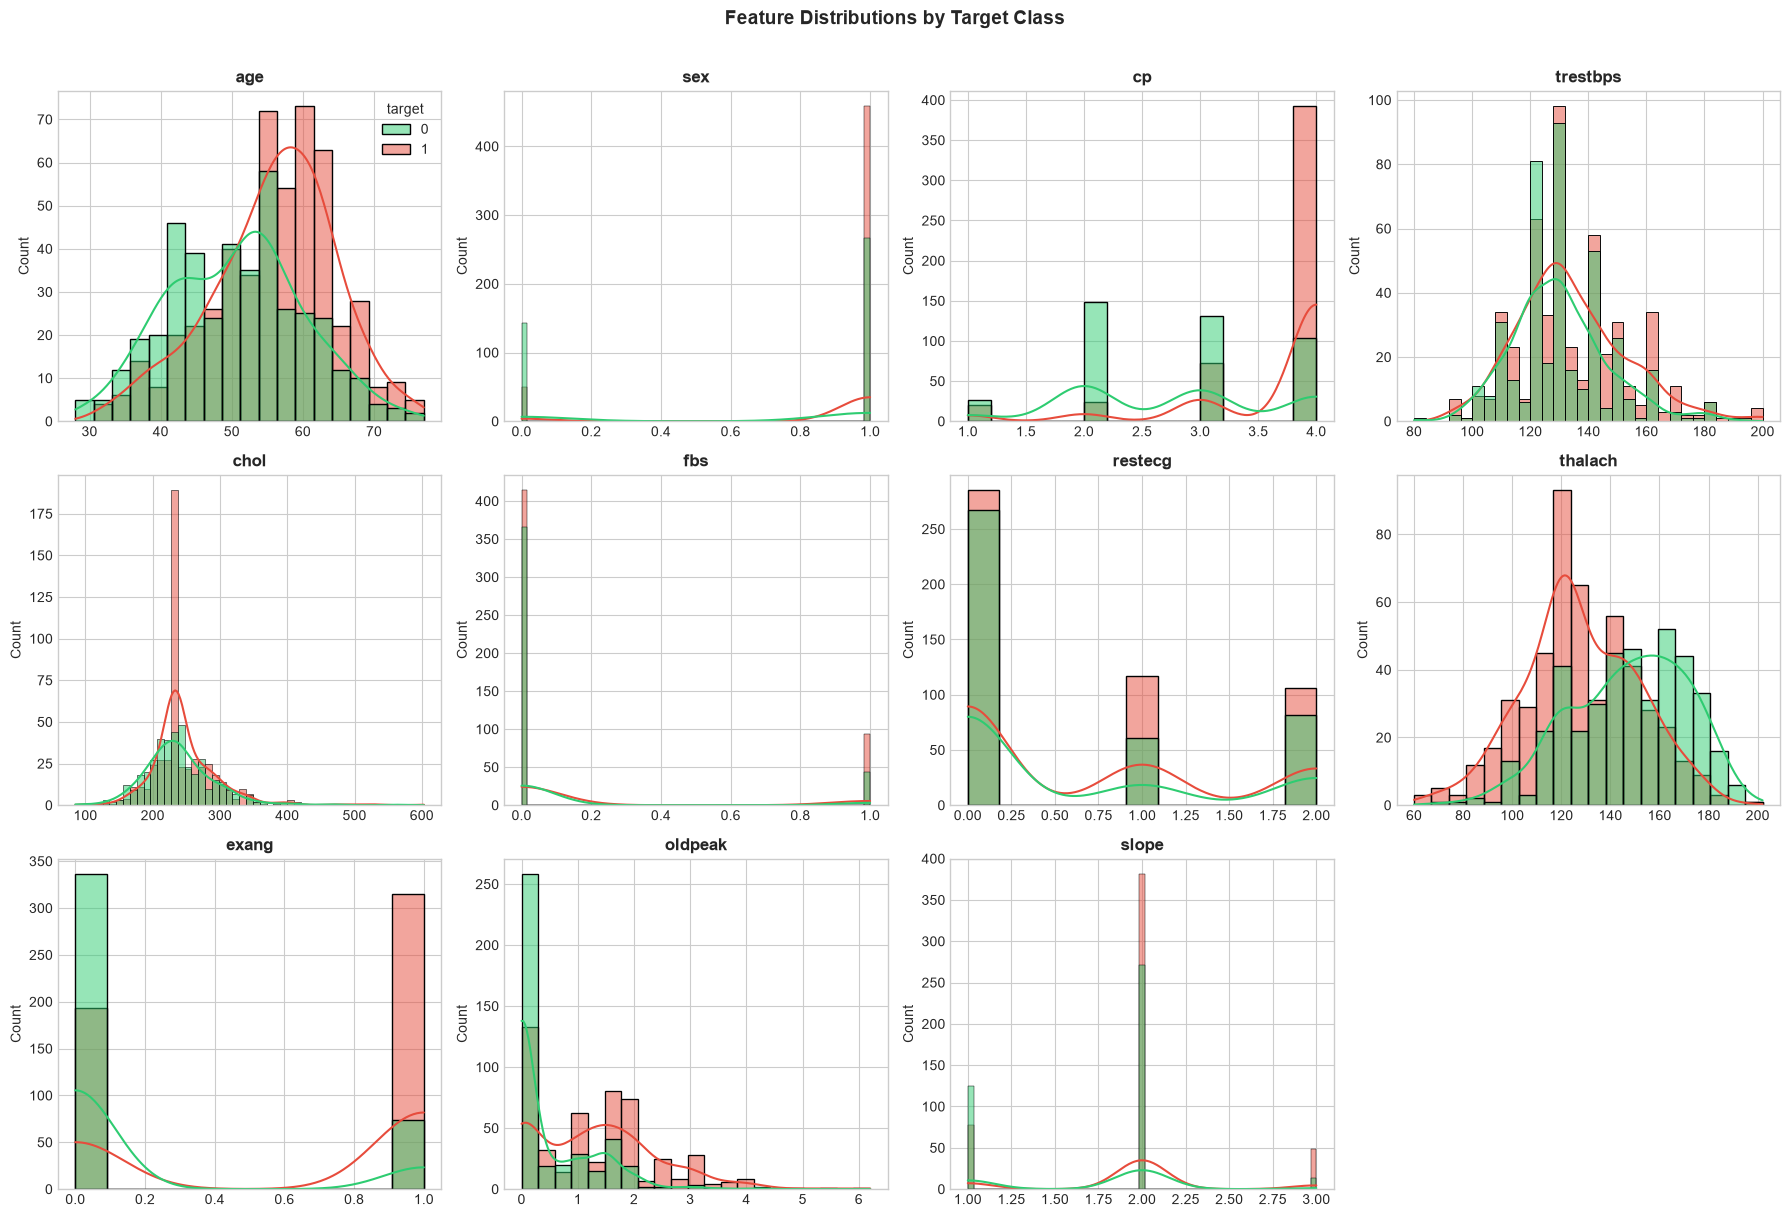


Key Observations:
- Histograms colored by target class help identify which features separate the classes.
- Overlapping distributions suggest weak discriminators; separated distributions are strong predictors.


In [6]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.histplot(data=df, x=col, hue=TARGET_COL, kde=True,
                     palette={0: '#2ecc71', 1: '#e74c3c'},
                     ax=axes[i], alpha=0.5, legend=(i == 0))
        axes[i].set_title(f"{col}", fontweight='bold')
        axes[i].set_xlabel("")
        axes[i].set_ylabel("Count")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Feature Distributions by Target Class", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\nKey Observations:")
print("- Histograms colored by target class help identify which features separate the classes.")
print("- Overlapping distributions suggest weak discriminators; separated distributions are strong predictors.")

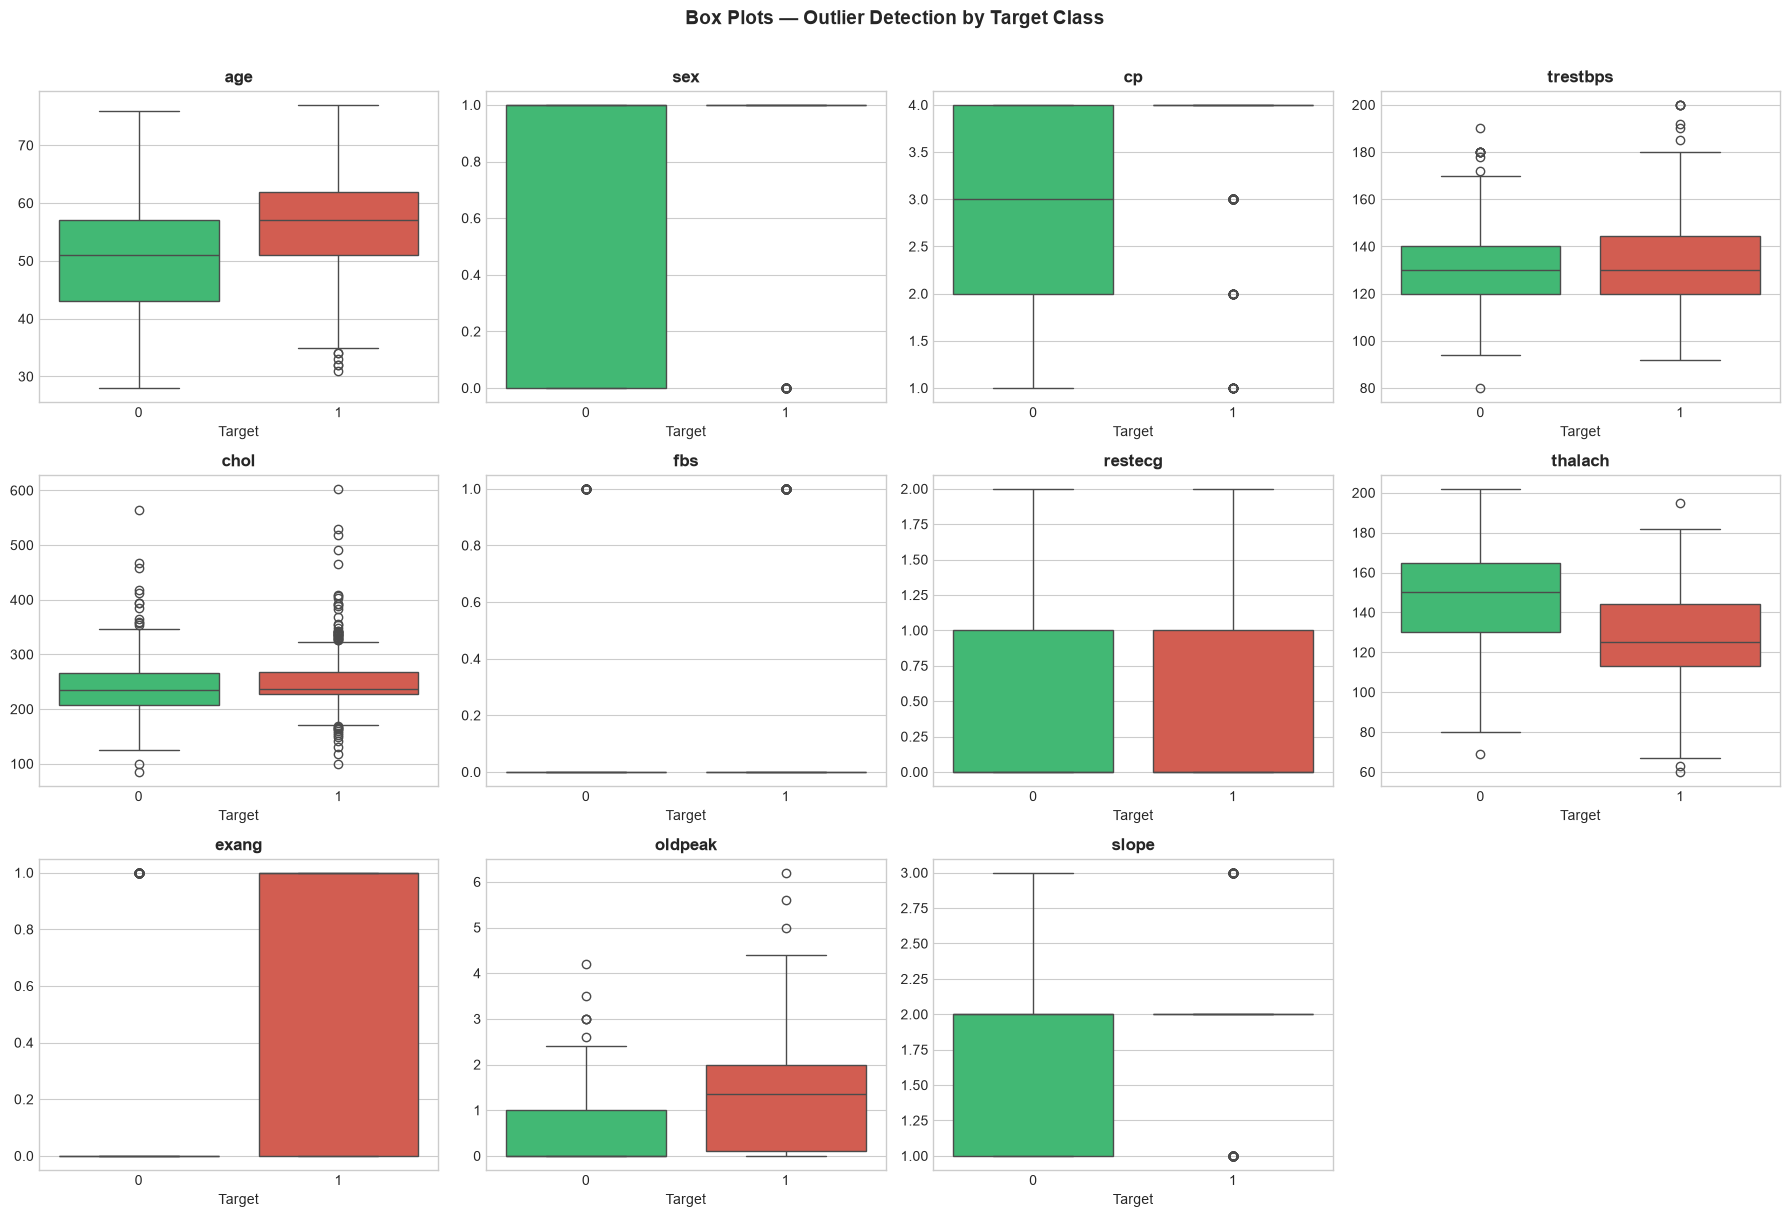

Box plot interpretation:
- Points beyond the whiskers are potential outliers (1.5 × IQR rule).
- Outliers may be genuine rare cases or data-entry errors — investigate before removing.


In [7]:
fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    if i < len(axes):
        sns.boxplot(data=df, y=col, x=TARGET_COL, hue=TARGET_COL,
                    palette={0: '#2ecc71', 1: '#e74c3c'},
                    ax=axes[i], legend=False)
        axes[i].set_title(f"{col}", fontweight='bold')
        axes[i].set_xlabel("Target")
        axes[i].set_ylabel("")

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("Box Plots — Outlier Detection by Target Class", fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("Box plot interpretation:")
print("- Points beyond the whiskers are potential outliers (1.5 × IQR rule).")
print("- Outliers may be genuine rare cases or data-entry errors — investigate before removing.")

### 2.5 Outlier Detection — IQR Method

The IQR (Interquartile Range) method flags any value below Q1 − 1.5×IQR or above Q3 + 1.5×IQR as a potential outlier — exactly the values a box plot draws as individual points beyond its whiskers.

> **Rule:** An outlier is a *question*, not a verdict: investigate whether it is a real value or an error before deciding to keep, cap, or remove it. Never delete outliers silently.

In [8]:
print("=" * 70)
print("OUTLIER DETECTION — IQR METHOD")
print("=" * 70)
print(f"Rule: flag values < Q1 − 1.5×IQR or > Q3 + 1.5×IQR\n")

outlier_summary = []

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    n_outliers = len(outliers)
    pct_outliers = (n_outliers / len(df)) * 100
    
    outlier_summary.append({
        'Feature': col,
        'Q1': round(Q1, 3),
        'Q3': round(Q3, 3),
        'IQR': round(IQR, 3),
        'Lower Bound': round(lower_bound, 3),
        'Upper Bound': round(upper_bound, 3),
        'Outliers': n_outliers,
        '% Outliers': round(pct_outliers, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

significant = outlier_df[outlier_df['% Outliers'] > 1]
if len(significant) > 0:
    print(f"\n⚠ Features with >1% outliers: {significant['Feature'].tolist()}")
    print("These may need capping, transformation, or careful investigation.")
else:
    print("\n✓ No features with >1% outliers — data is relatively clean.")

OUTLIER DETECTION — IQR METHOD
Rule: flag values < Q1 − 1.5×IQR or > Q3 + 1.5×IQR

 Feature     Q1     Q3   IQR  Lower Bound  Upper Bound  Outliers  % Outliers
     age  47.00  60.00 13.00       27.500       79.500         0        0.00
     sex   1.00   1.00  0.00        1.000        1.000       193       21.02
      cp   3.00   4.00  1.00        1.500        5.500        46        5.01
trestbps 120.00 140.00 20.00       90.000      170.000        27        2.94
    chol 217.25 267.00 49.75      142.625      341.625        44        4.79
     fbs   0.00   0.00  0.00        0.000        0.000       138       15.03
 restecg   0.00   1.00  1.00       -1.500        2.500         0        0.00
 thalach 120.00 155.75 35.75       66.375      209.375         2        0.22
   exang   0.00   1.00  1.00       -1.500        2.500         0        0.00
 oldpeak   0.00   1.50  1.50       -2.250        3.750        15        1.63
   slope   2.00   2.00  0.00        2.000        2.000       266      

### 2.6 Correlation Analysis

Correlation measures how strongly two numeric variables move together, on a scale from −1 to +1.

| Value | Meaning |
|:------|:--------|
| **+1** | Perfect positive relationship |
| **0** | No linear relationship |
| **−1** | Perfect negative relationship |

> ⚠️ **Correlation is not causation.** Two variables moving together does not mean one causes the other. EDA identifies relationships; it never proves cause.

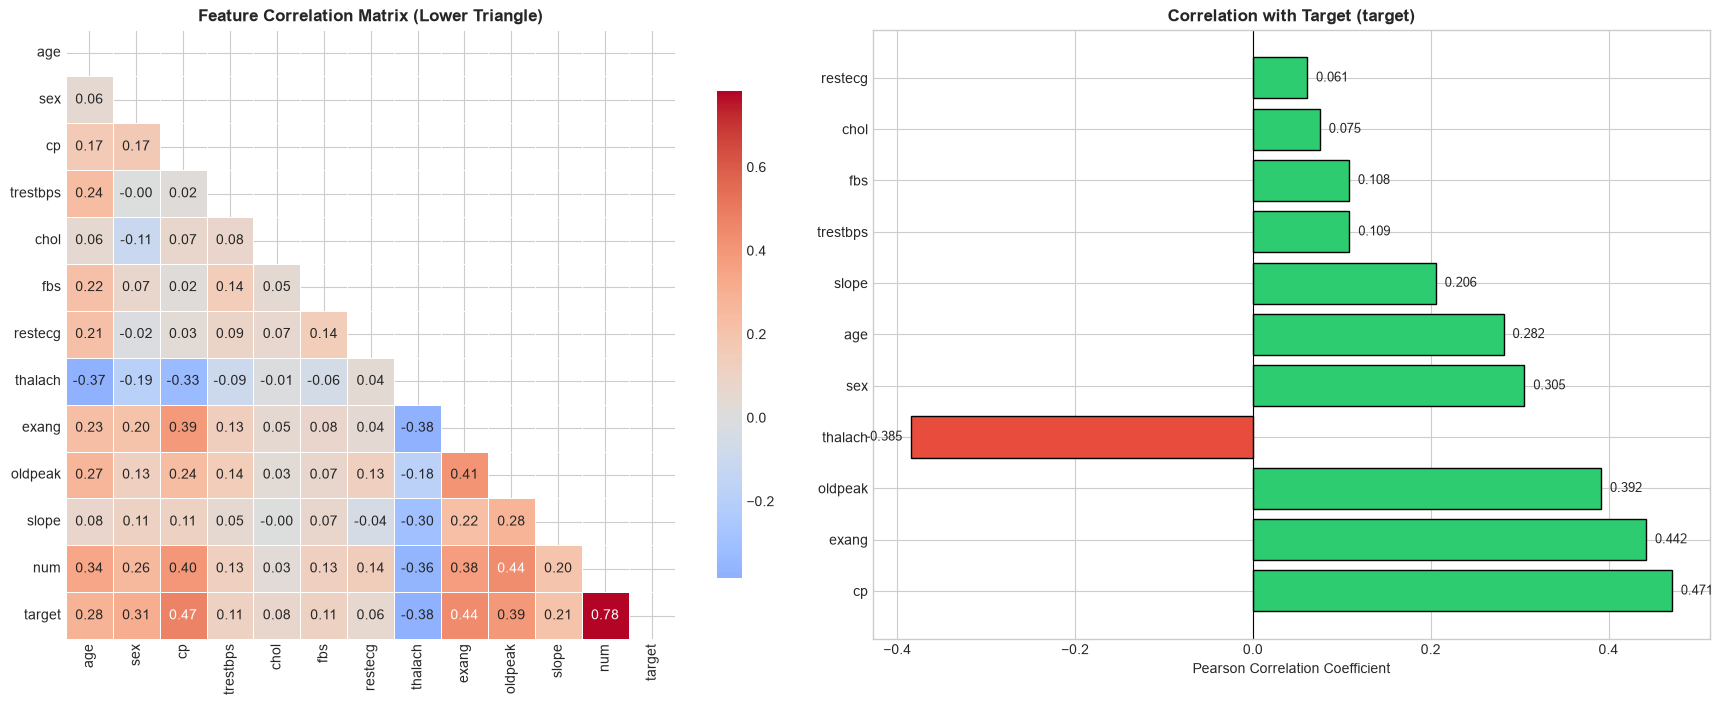


Top 5 Features Correlated with Target:
--------------------------------------------------
  cp             : +0.471 (positive)
  exang          : +0.442 (positive)
  oldpeak        : +0.392 (positive)
  thalach        : -0.385 (negative)
  sex            : +0.305 (positive)


In [9]:
# Correlation matrix — include both targets for full context, features only are 'numeric_cols'
corr = df[numeric_cols + TARGET_COLS].corr()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Lower-triangle heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm',
            center=0, ax=axes[0], square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Feature Correlation Matrix (Lower Triangle)", fontweight='bold')

# Top correlations with target — exclude both target columns
target_corr = corr[TARGET_COL].drop(TARGET_COLS).sort_values(key=abs, ascending=False)
colors_bar = ['#e74c3c' if x < 0 else '#2ecc71' for x in target_corr]
bars = axes[1].barh(target_corr.index, target_corr.values, color=colors_bar, edgecolor='black')
axes[1].set_title(f"Correlation with Target ({TARGET_COL})", fontweight='bold')
axes[1].set_xlabel("Pearson Correlation Coefficient")
axes[1].axvline(x=0, color='black', linewidth=0.8)

for bar, val in zip(bars, target_corr.values):
    x_pos = val + 0.01 if val >= 0 else val - 0.01
    axes[1].text(x_pos, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', ha='left' if val >= 0 else 'right', fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop 5 Features Correlated with Target:")
print("-" * 50)
for feat, corr_val in target_corr.head(5).items():
    direction = "positive" if corr_val > 0 else "negative"
    print(f"  {feat:15s}: {corr_val:+.3f} ({direction})")

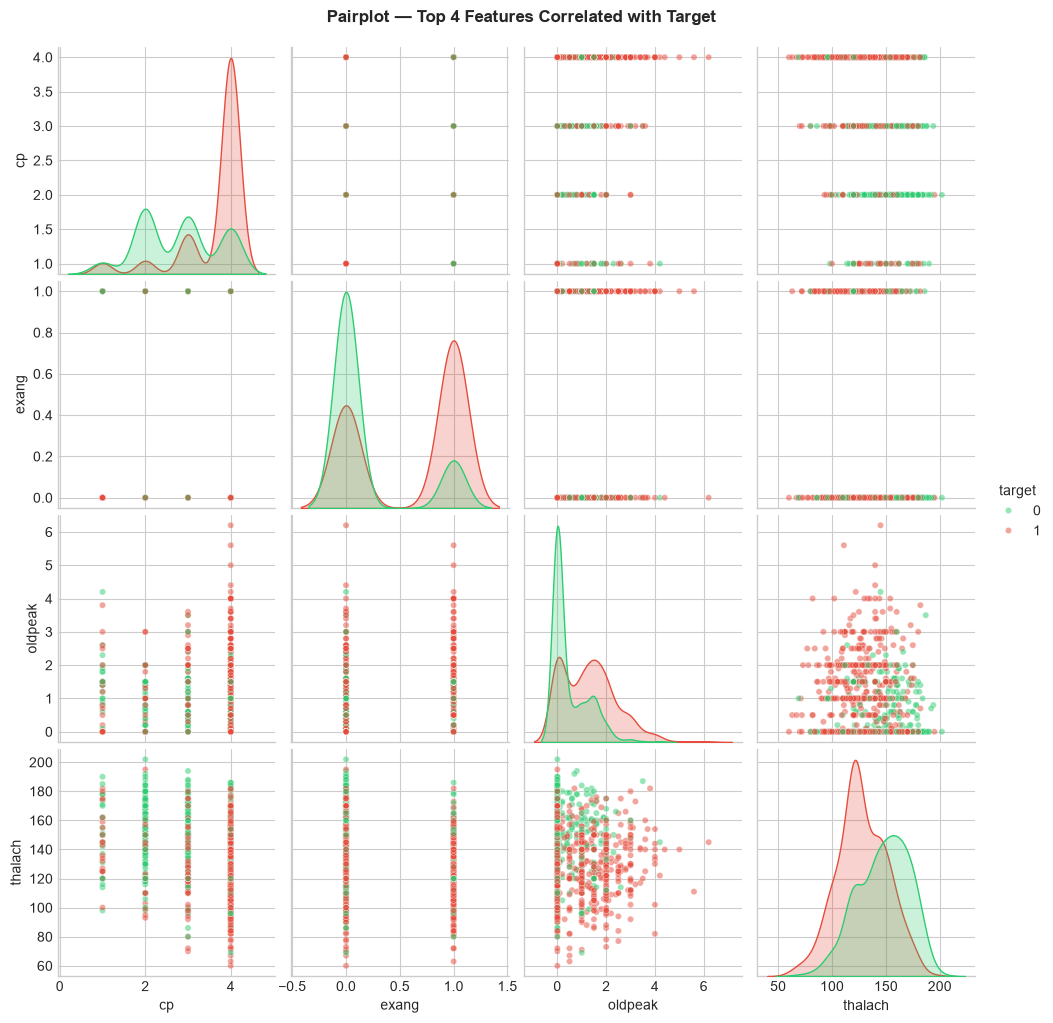

Pairplot reveals:
- Diagonal: distribution shape of each feature (separated = good predictor).
- Off-diagonal: pairwise relationships between features.
- Clear class separation in scatter plots indicates strong predictive power.


In [10]:
top_features = target_corr.head(4).index.tolist() + [TARGET_COL]

g = sns.pairplot(df[top_features], hue=TARGET_COL,
                 palette={0: '#2ecc71', 1: '#e74c3c'},
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
g.figure.suptitle("Pairplot — Top 4 Features Correlated with Target", y=1.02, fontweight='bold')
plt.show()

print("Pairplot reveals:")
print("- Diagonal: distribution shape of each feature (separated = good predictor).")
print("- Off-diagonal: pairwise relationships between features.")
print("- Clear class separation in scatter plots indicates strong predictive power.")

### 2.7 Data Storytelling — Key Findings

Summarizing the EDA insights that will guide our modeling decisions:

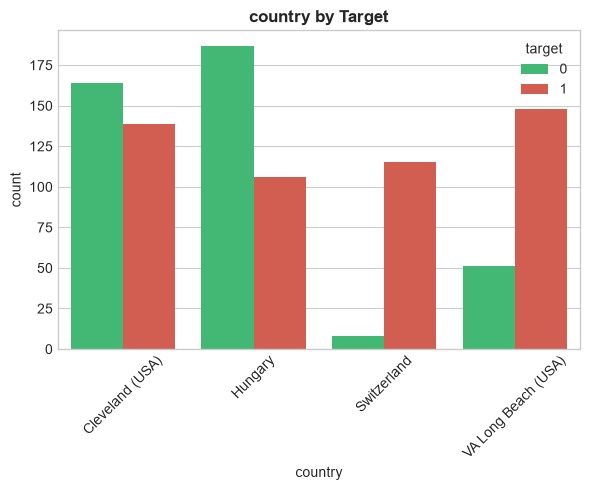


FEATURE SCALE COMPARISON

Features with vastly different scales will benefit from StandardScaler:

  age            : range [28.0, 77.0], std=9.43
  sex            : range [0.0, 1.0], std=0.41
  cp             : range [1.0, 4.0], std=0.93
  trestbps       : range [80.0, 200.0], std=17.93
  chol           : range [85.0, 603.0], std=52.04
  fbs            : range [0.0, 1.0], std=0.36
  restecg        : range [0.0, 2.0], std=0.81
  thalach        : range [60.0, 202.0], std=25.48
  exang          : range [0.0, 1.0], std=0.49
  oldpeak        : range [0.0, 6.2], std=1.04
  slope          : range [1.0, 3.0], std=0.52


In [11]:
# Categorical feature analysis (if any)
if categorical_cols:
    fig, axes = plt.subplots(1, len(categorical_cols), figsize=(6*len(categorical_cols), 5))
    if len(categorical_cols) == 1:
        axes = [axes]
    
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, hue=TARGET_COL, palette={0: '#2ecc71', 1: '#e74c3c'}, ax=axes[i])
        axes[i].set_title(f"{col} by Target", fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical features found (all numeric).")

# Feature scale comparison
print("\n" + "=" * 70)
print("FEATURE SCALE COMPARISON")
print("=" * 70)
print("\nFeatures with vastly different scales will benefit from StandardScaler:\n")
for col in numeric_cols:
    print(f"  {col:15s}: range [{df[col].min():.1f}, {df[col].max():.1f}], std={df[col].std():.2f}")

####  EDA Summary — Findings → Pipeline Implications

| Finding | Implication for Pipeline |
|:--------|:------------------------|
| **No missing values** | `SimpleImputer` is a safety net, not strictly needed |
| **Class imbalance** | Use F1-score and ROC-AUC (not just accuracy) |
| **Different feature scales** | `StandardScaler` is essential for Logistic Regression |
| **`num` column is target-derived** | Must be dropped to prevent data leakage |
| **`country` is categorical** | `OneHotEncoder` needed |
| **Outliers detected** | Logistic Regression is robust; monitor for influence |
| **`cp`, `thalach`, `oldpeak` correlate most with target** | These are key predictors to watch |

---
##  Task 3 & 4: Preprocessing & Baseline Model Pipeline

To prevent data leakage, all preprocessing is encapsulated in a single Scikit-learn `Pipeline`. Every step is fitted **only on the training data**.

| Component | Method | Purpose |
|:----------|:-------|:--------|
| **Numerical** | `SimpleImputer(median)` + `StandardScaler` | Handle missing values; normalize scale |
| **Categorical** | `SimpleImputer(most_frequent)` + `OneHotEncoder` | Handle missing values; convert to numeric |
| **Classifier** | `LogisticRegression(L2, max_iter=1000)` | Baseline model from Week 3 |

> **Critical Rule:** Fit the scaler on the training data only, then apply it to the test data. Fitting on the full dataset leaks information from the test set into training.

In [12]:
# Features and target split
X = df.drop(columns=['target', 'num'])  # Drop target + target-derived column
y = df[TARGET_COL]

print(f"Features shape: {X.shape}")
print(f"Target distribution: {y.value_counts().to_dict()}")

# Stratified 80/20 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain set: {X_train.shape[0]} samples")
print(f"Test set:  {X_test.shape[0]} samples")
print(f"\nTrain target distribution: {y_train.value_counts().to_dict()}")
print(f"Test target distribution:  {y_test.value_counts().to_dict()}")

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category', 'string']).columns.tolist()

print(f"\nNumeric features ({len(numeric_features)}): {numeric_features}")
print(f"Categorical features ({len(categorical_features)}): {categorical_features}")

Features shape: (918, 12)
Target distribution: {1: 508, 0: 410}

Train set: 734 samples
Test set:  184 samples

Train target distribution: {1: 406, 0: 328}
Test target distribution:  {1: 102, 0: 82}

Numeric features (11): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope']
Categorical features (1): ['country']


In [13]:
# Define numerical and categorical transformers
num_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Combine transformers into ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, numeric_features),
        ('cat', cat_pipeline, categorical_features)
    ]
)

# Assemble full baseline pipeline
baseline_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

# Fit baseline on training set only
baseline_model.fit(X_train, y_train)

print("✓ Baseline model trained successfully.")
print(f"  Pipeline steps: {[name for name, _ in baseline_model.steps]}")
print(f"  Leakage check: Scaler fitted on train only, applied to test via transform().")

✓ Baseline model trained successfully.
  Pipeline steps: ['preprocessor', 'classifier']
  Leakage check: Scaler fitted on train only, applied to test via transform().


---
##  Task 5: Evaluation & Performance Metric Logging

We evaluate the baseline using three complementary metrics:

| Metric | Formula | Answers |
|:-------|:--------|:--------|
| **Accuracy** | (TP + TN) / Total | Overall correctness |
| **F1-Score** | 2 × (Precision × Recall) / (Precision + Recall) | Balanced precision/recall |
| **ROC-AUC** | Area under ROC curve | Discrimination ability across thresholds |

> **Why not just accuracy?** With class imbalance, a model predicting "no disease" every time could score high accuracy while being useless.

In [14]:
y_pred = baseline_model.predict(X_test)
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print("=" * 50)
print("DAY 1 BASELINE MODEL EVALUATION")
print("=" * 50)
print(f"Accuracy : {acc:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}\n")
print("Classification Report:\n", classification_report(y_test, y_pred))

DAY 1 BASELINE MODEL EVALUATION
Accuracy : 0.8533
F1-Score : 0.8657
ROC-AUC  : 0.9159

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.85      0.84        82
           1       0.88      0.85      0.87       102

    accuracy                           0.85       184
   macro avg       0.85      0.85      0.85       184
weighted avg       0.85      0.85      0.85       184



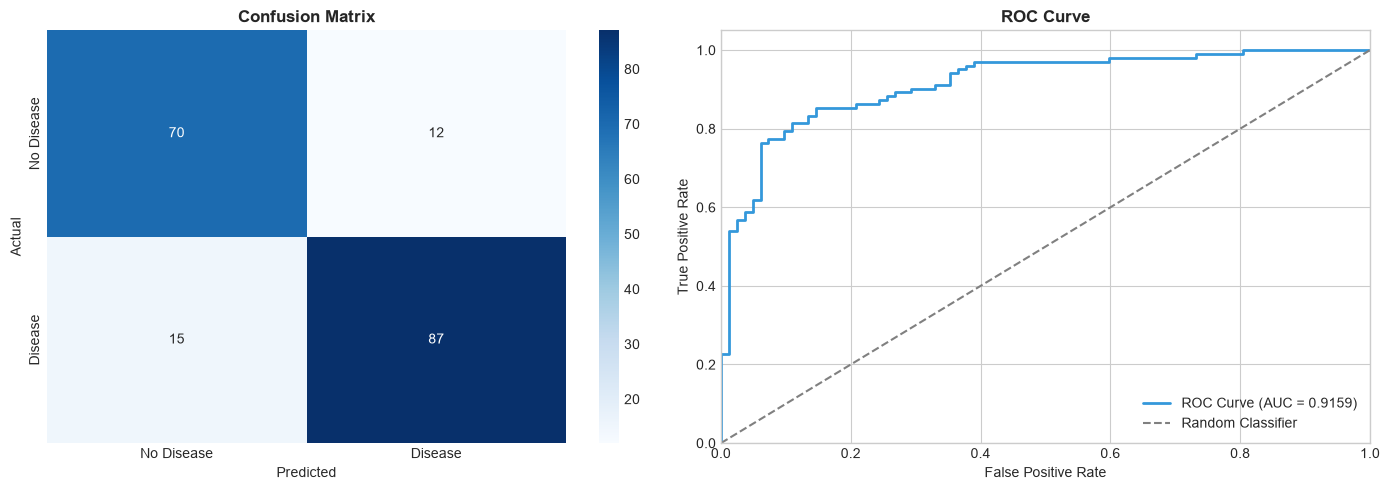

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_title("Confusion Matrix", fontweight='bold')
axes[0].set_ylabel("Actual")
axes[0].set_xlabel("Predicted")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='#3498db', linewidth=2, label=f'ROC Curve (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='gray', linestyle='--', label='Random Classifier')
axes[1].set_title("ROC Curve", fontweight='bold')
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.05])

plt.tight_layout()
plt.show()

---
## Benchmark Definition — What Every Later Model Must Beat

| Model Architecture | Accuracy | F1-Score | ROC-AUC |
|:-------------------|:---------|:---------|:--------|
| **Logistic Regression (Baseline)** | **0.8533** | **0.8657** | **0.9159** |

### Acceptance Criteria for Neural Network (Days 4–5)

Any deep learning model built using TensorFlow/Keras **must exceed**:

- **ROC-AUC > 0.9159**
- **F1-Score > 0.8657**

### Leakage Verification

-  Explicitly removed target-derived column `num` alongside `target`
-  No statistical properties of `X_test` were exposed during scaling or imputation
-  All preprocessing encapsulated in a single `Pipeline` object — no manual `fit_transform` on test data

---
##  Data Leakage Analysis — `num` vs `target`

The dataset contains **two target-like columns**:

| Column | Type | Values | Meaning |
|:-------|:-----|:-------|:--------|
| `num` | Multi-class | 0, 1, 2, 3, 4 | Original severity of heart disease |
| `target` | Binary | 0, 1 | Binarized version (0 = no disease, 1+ = disease) |

### The Link

- `num == 0` → `target == 0` (100% of the time, 410 rows)
- `num > 0` → `target == 1` (100% of the time, 508 rows)

`target` is **literally derived from `num`**. Including `num` as a feature means the model can learn the trivial rule `num > 0 → target = 1`, achieving **perfect scores** with zero learning.

> ⚠️ **This is DATA LEAKAGE.** The feature IS the answer. Any model trained with `num` as a feature is testing the model's ability to memorize, not to predict.

### Our Mitigation

-  Both `target` (the label) AND `num` (the target-derived column) are dropped from features
-  The code cell below proves the leakage by comparing model performance with and without `num`

In [16]:
# ================================================================
# DATA LEAKAGE ANALYSIS: num vs target
# ================================================================
# The dataset contains TWO target-like columns:
#   - num:      original multi-class severity (0, 1, 2, 3, 4)
#   - target:   binarized version (0 = no disease, 1 = disease)
#
# If 'num' is kept as a feature, the model can learn the trivial
# rule: num > 0  =>  target = 1,  yielding perfect scores.
# This is DATA LEAKAGE — the feature IS the answer.
# ================================================================

print("=" * 60)
print("DATA LEAKAGE ANALYSIS: num vs target")
print("=" * 60)

# 1. Examine the relationship
ct = pd.crosstab(df['num'], df['target'], margins=True)
print("\nCross-tabulation: num vs target")
print("-" * 40)
print(ct)

# 2. Perfect linking check
num_gt_zero = df[df['num'] > 0]
num_eq_zero = df[df['num'] == 0]
print(f"\nWhen num > 0:  {len(num_gt_zero)} rows, ALL have target=1  ({(num_gt_zero['target']==1).sum()}/{len(num_gt_zero)})")
print(f"When num == 0: {len(num_eq_zero)} rows, ALL have target=0  ({(num_eq_zero['target']==0).sum()}/{len(num_eq_zero)})")
print(f"\nConclusion: num and target are 100% perfectly linked.")
print(f"             num is the DIRECT source of target.")

# 3. Proof: model WITH leakage vs WITHOUT leakage
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import roc_auc_score, f1_score

y = df['target']

# --- WITH leakage (num kept) ---
X_leak = df.drop(columns=['target'])
X_tr, X_te, y_tr, y_te = train_test_split(X_leak, y, test_size=0.2, random_state=42, stratify=y)
num_f = X_leak.select_dtypes(include=['int64','float64']).columns.tolist()
cat_f = X_leak.select_dtypes(include=['object','string']).columns.tolist()
pre_leak = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), num_f),
    ('cat', Pipeline([('enc', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_f)
])
pipe_leak = Pipeline([('pre', pre_leak), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
pipe_leak.fit(X_tr, y_tr)
auc_leak = roc_auc_score(y_te, pipe_leak.predict_proba(X_te)[:, 1])
f1_leak  = f1_score(y_te, pipe_leak.predict(X_te))

# --- WITHOUT leakage (num dropped) ---
X_clean = df.drop(columns=['target', 'num'])
X_tr2, X_te2, y_tr2, y_te2 = train_test_split(X_clean, y, test_size=0.2, random_state=42, stratify=y)
num_f2 = X_clean.select_dtypes(include=['int64','float64']).columns.tolist()
cat_f2 = X_clean.select_dtypes(include=['object','string']).columns.tolist()
pre_clean = ColumnTransformer([
    ('num', Pipeline([('scaler', StandardScaler())]), num_f2),
    ('cat', Pipeline([('enc', OneHotEncoder(handle_unknown='ignore', drop='first'))]), cat_f2)
])
pipe_clean = Pipeline([('pre', pre_clean), ('clf', LogisticRegression(max_iter=1000, random_state=42))])
pipe_clean.fit(X_tr2, y_tr2)
auc_clean = roc_auc_score(y_te2, pipe_clean.predict_proba(X_te2)[:, 1])
f1_clean  = f1_score(y_te2, pipe_clean.predict(X_te2))

print("\n" + "=" * 60)
print("PROOF: Leakage Effect on Model Performance")
print("=" * 60)
print(f"{'Scenario':<40} {'AUC':>8} {'F1':>8}")
print("-" * 58)
print(f"{'WITH num as feature (LEAKAGE)':<40} {auc_leak:>8.4f} {f1_leak:>8.4f}")
print(f"{'WITHOUT num (CLEAN)':<40} {auc_clean:>8.4f} {f1_clean:>8.4f}")
print("-" * 58)
print(f"\nAUC gap: {auc_leak - auc_clean:.4f}  |  F1 gap: {f1_leak - f1_clean:.4f}")
print(f"\nVerdict: Including 'num' creates perfect but FAKE scores.")
print(f"         This notebook correctly drops both 'target' and 'num'.")

DATA LEAKAGE ANALYSIS: num vs target

Cross-tabulation: num vs target
----------------------------------------
target    0    1  All
num                  
0       410    0  410
1         0  265  265
2         0  108  108
3         0  107  107
4         0   28   28
All     410  508  918

When num > 0:  508 rows, ALL have target=1  (508/508)
When num == 0: 410 rows, ALL have target=0  (410/410)

Conclusion: num and target are 100% perfectly linked.
             num is the DIRECT source of target.

PROOF: Leakage Effect on Model Performance
Scenario                                      AUC       F1
----------------------------------------------------------
WITH num as feature (LEAKAGE)              1.0000   1.0000
WITHOUT num (CLEAN)                        0.9159   0.8657
----------------------------------------------------------

AUC gap: 0.0841  |  F1 gap: 0.1343

Verdict: Including 'num' creates perfect but FAKE scores.
         This notebook correctly drops both 'target' and 'num'.


In [17]:
# ─── Sprint 1 — Day 1 Final Summary ───
print("=" * 60)
print("SPRINT 1 — DAY 1 COMPLETE")
print("=" * 60)
print(f"\nDataset: {df.shape[0]} samples, {X.shape[1]} features")
print(f"Train/Test split: {len(X_train)}/{len(X_test)} (80/20, stratified)")
print(f"\nBaseline Model: Logistic Regression (L2 regularization)")
print(f"\n{'Metric':<15} {'Score':>10}")
print("-" * 26)
print(f"{'Accuracy':<15} {acc:>10.4f}")
print(f"{'F1-Score':<15} {f1:>10.4f}")
print(f"{'ROC-AUC':<15} {auc:>10.4f}")
print(f"\n{'='*60}")
print(f" NEURAL NETWORK MUST BEAT: F1 > {f1:.4f}, AUC > {auc:.4f}")
print(f"{'='*60}")

SPRINT 1 — DAY 1 COMPLETE

Dataset: 918 samples, 12 features
Train/Test split: 734/184 (80/20, stratified)

Baseline Model: Logistic Regression (L2 regularization)

Metric               Score
--------------------------
Accuracy            0.8533
F1-Score            0.8657
ROC-AUC             0.9159

 NEURAL NETWORK MUST BEAT: F1 > 0.8657, AUC > 0.9159
